# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

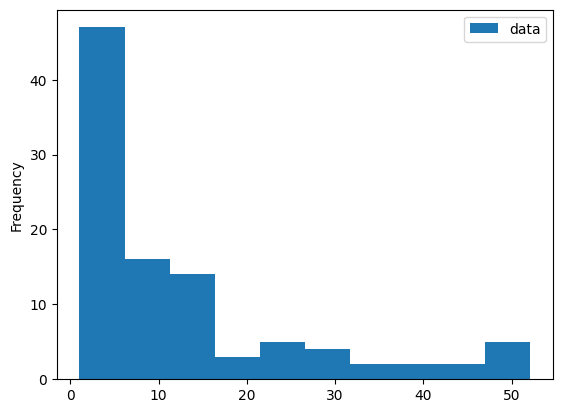

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

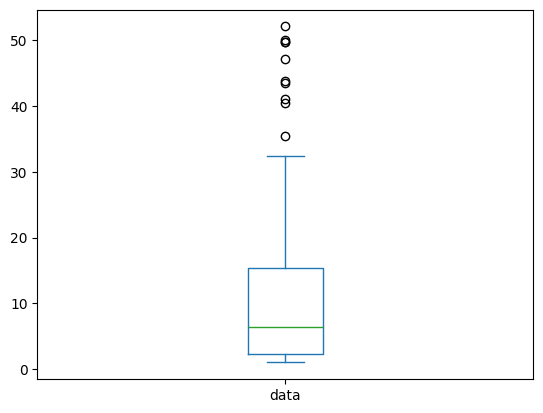

In [3]:
df.plot.box()

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

### 3.1 Histograms and Histogram Variants

Plotting: Diabetes_012


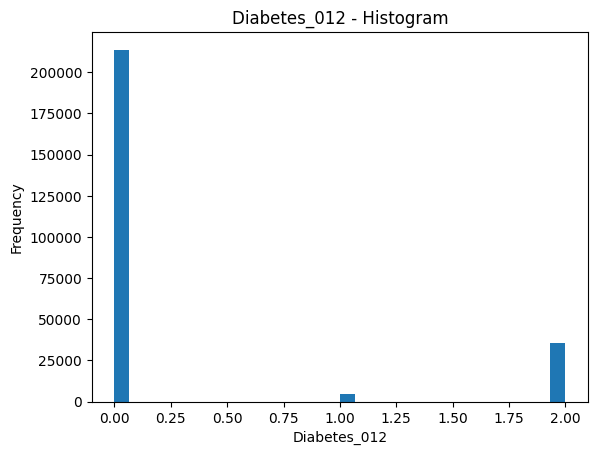

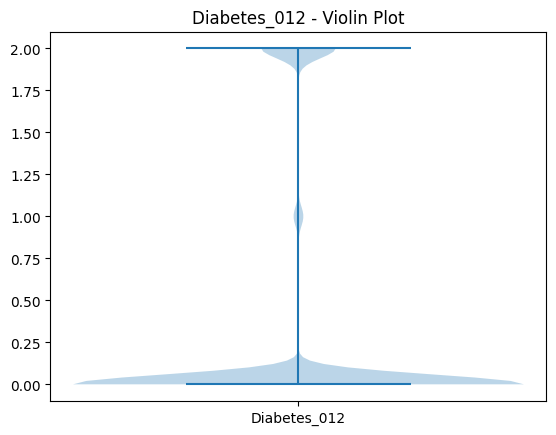

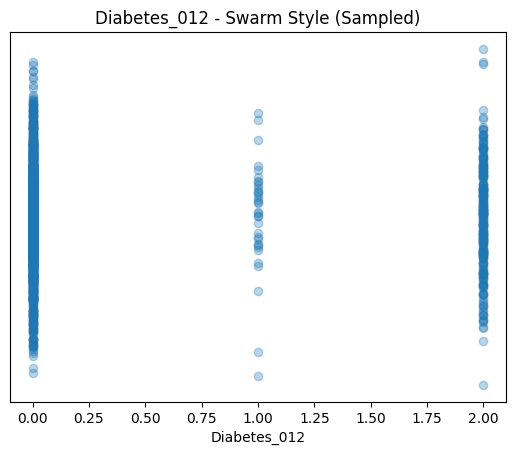

Plotting: HighBP


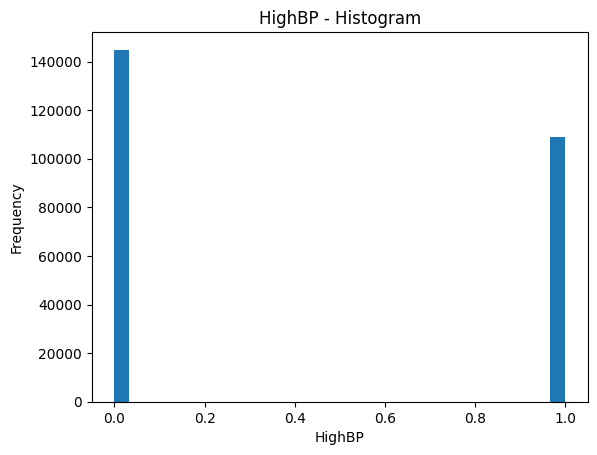

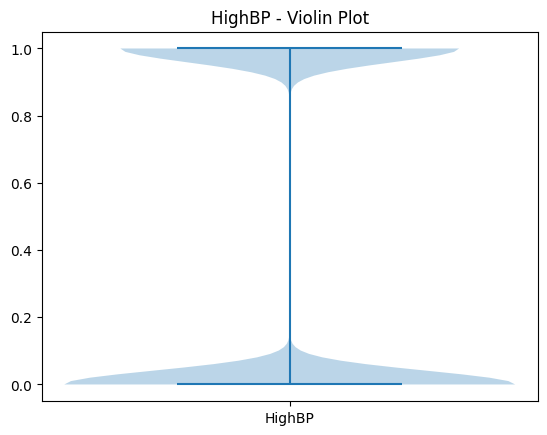

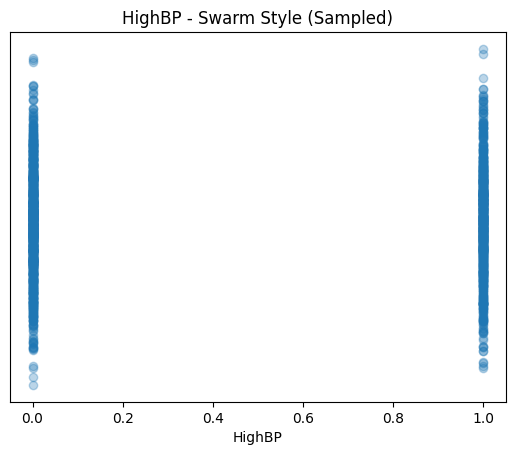

Plotting: HighChol


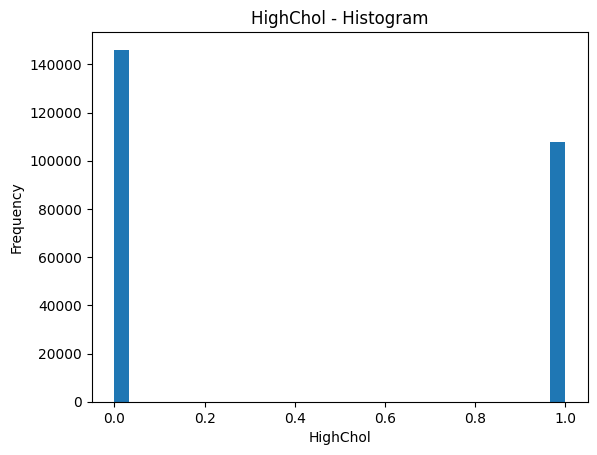

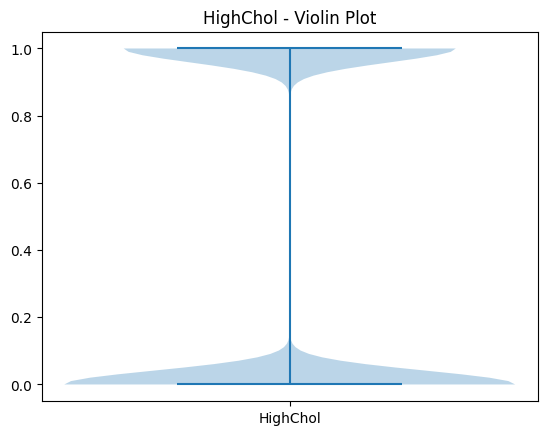

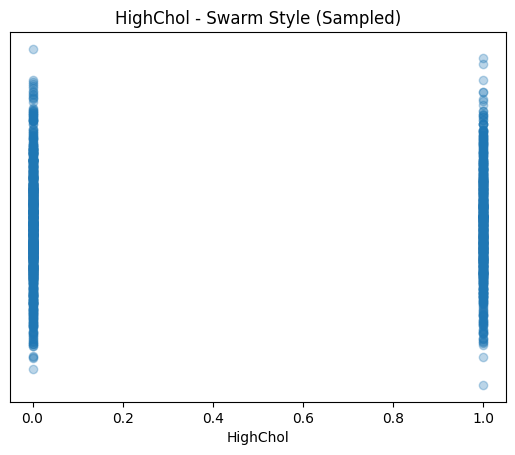

Plotting: CholCheck


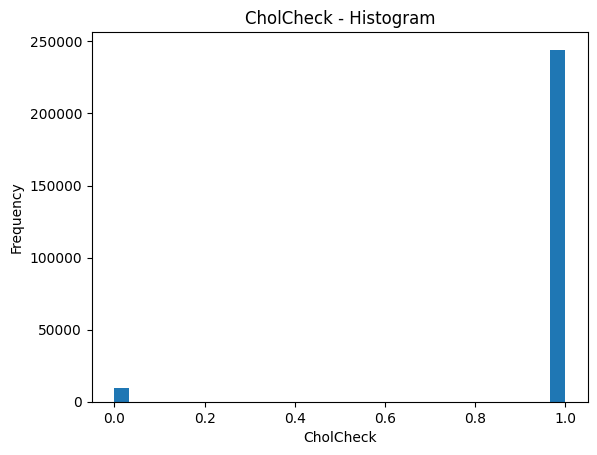

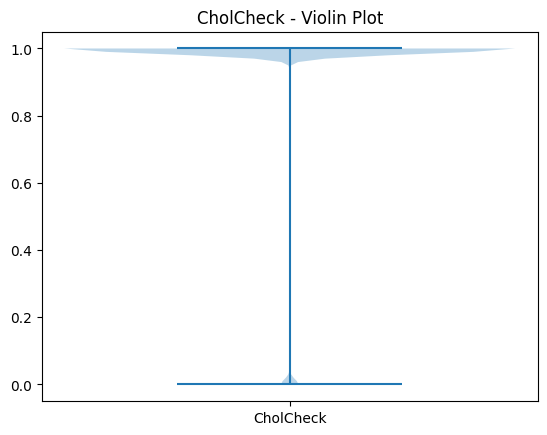

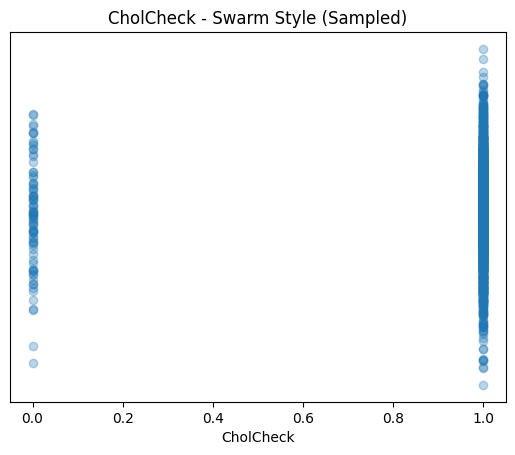

Plotting: BMI


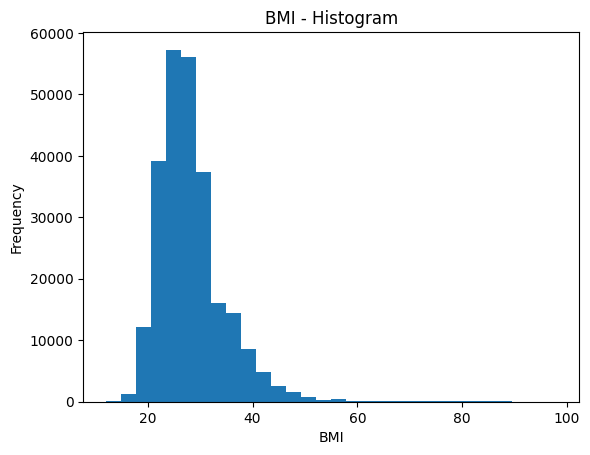

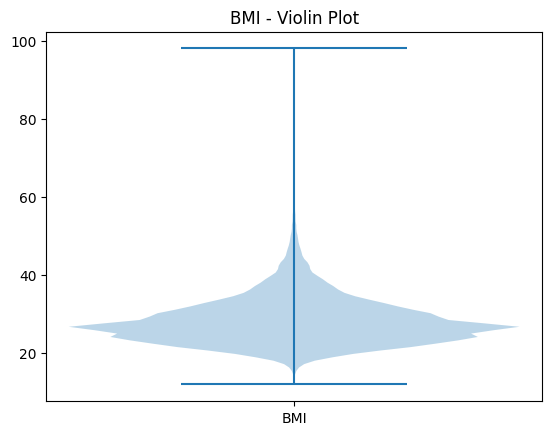

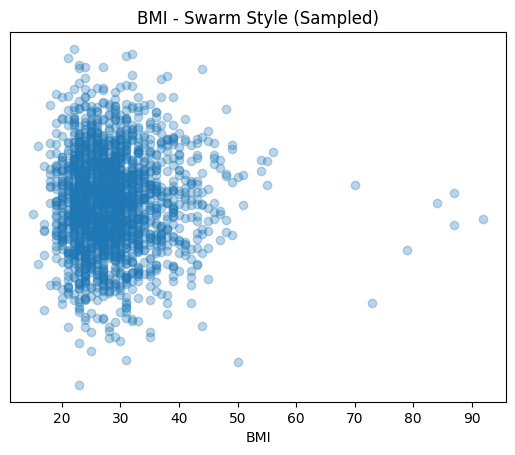

Plotting: Smoker


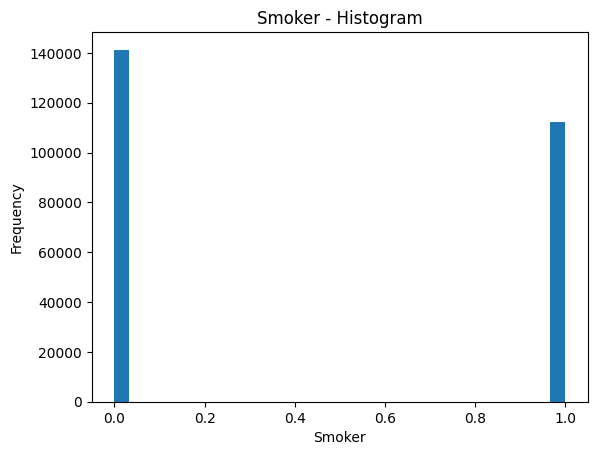

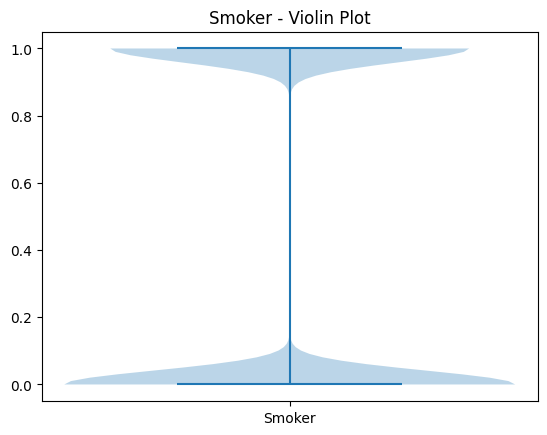

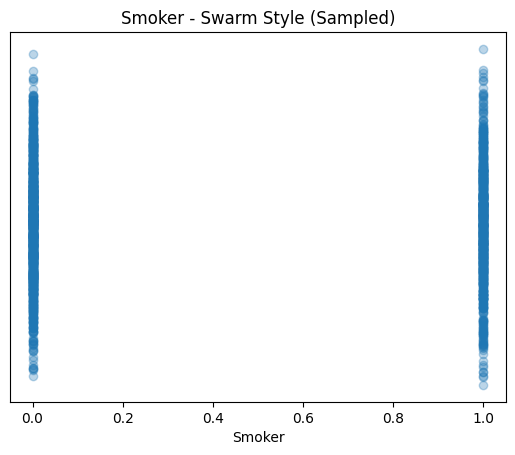

Plotting: Stroke


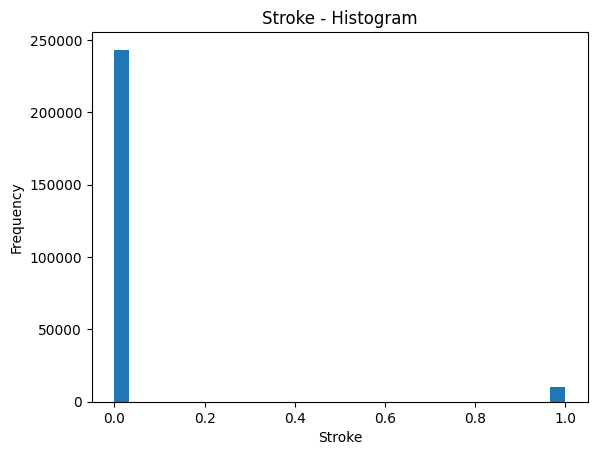

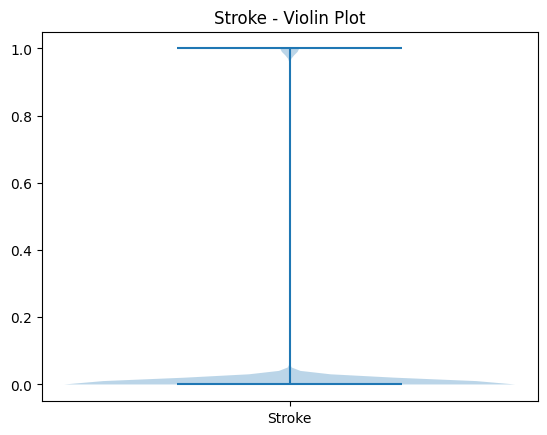

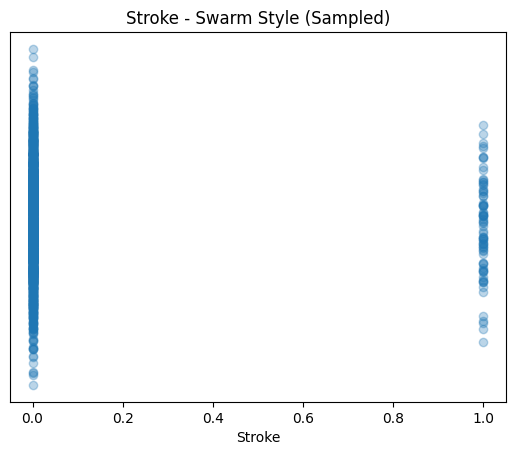

Plotting: HeartDiseaseorAttack


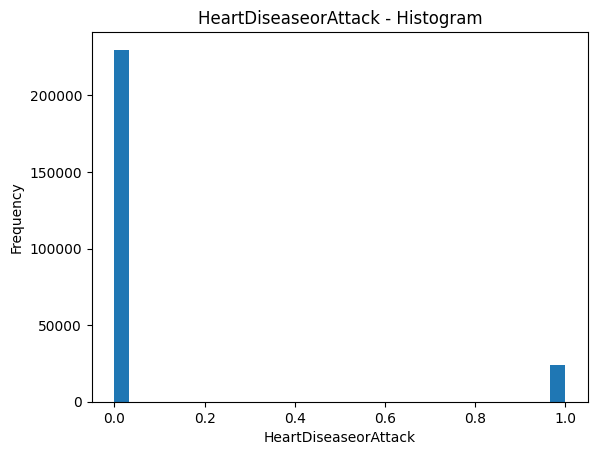

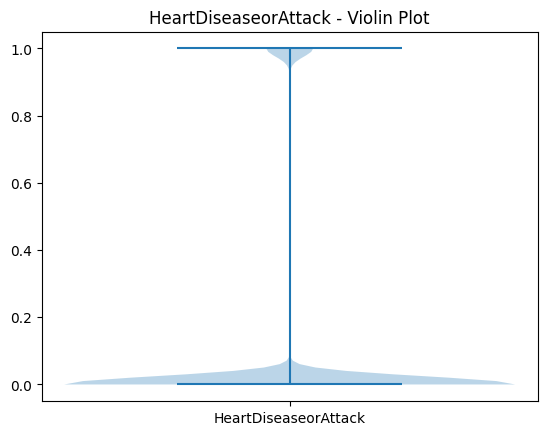

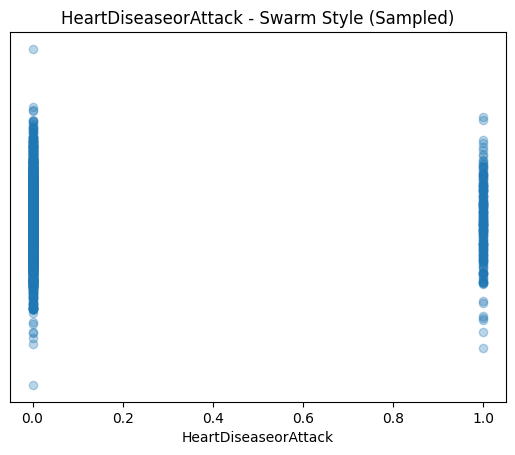

Plotting: PhysActivity


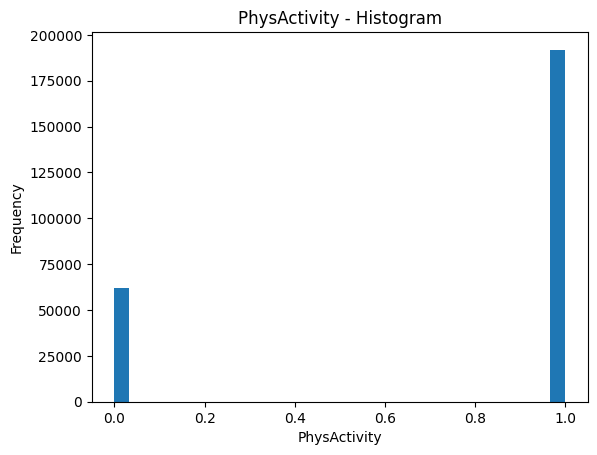

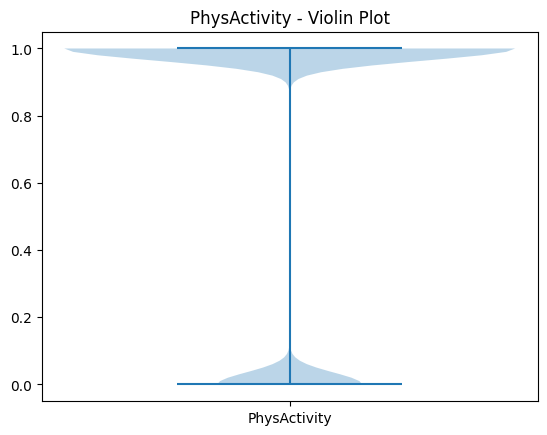

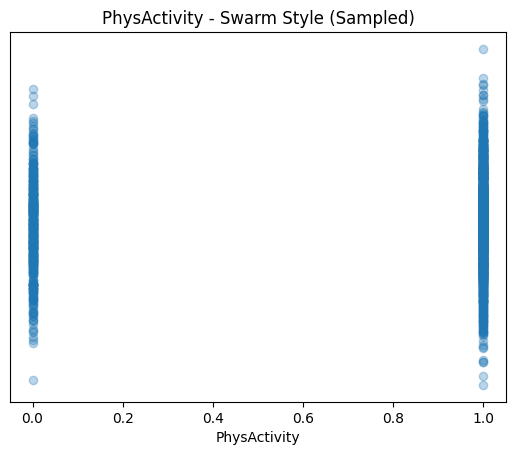

Plotting: Fruits


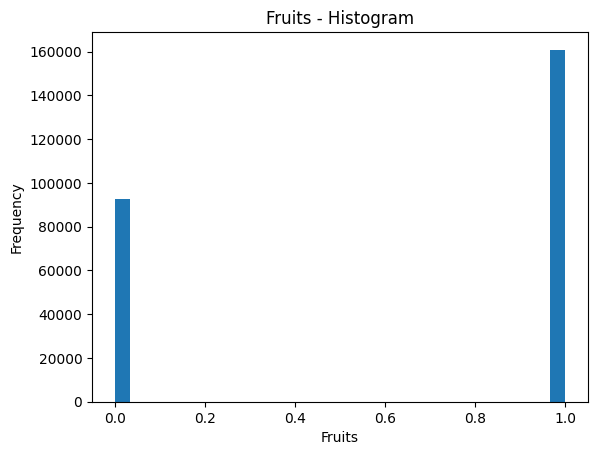

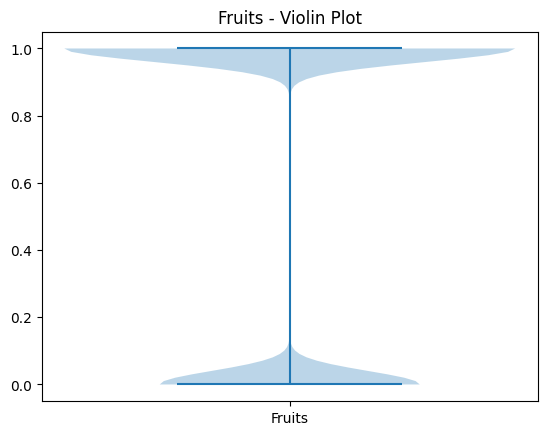

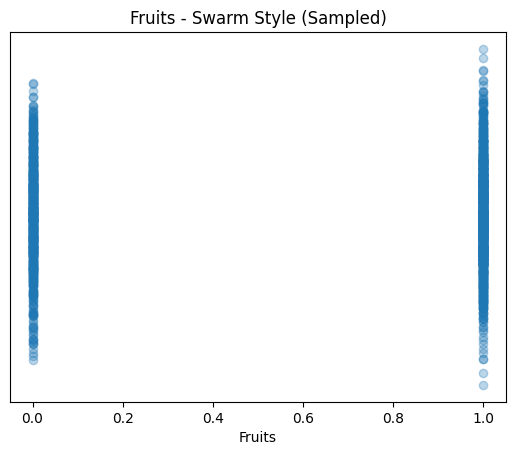

Plotting: Veggies


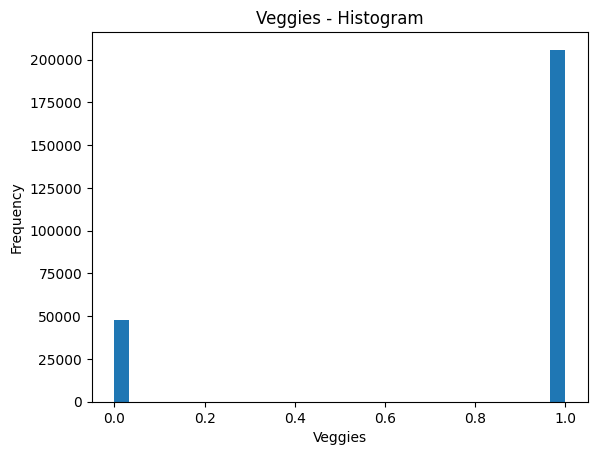

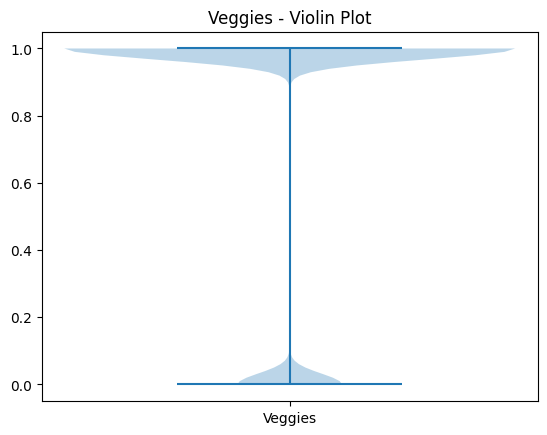

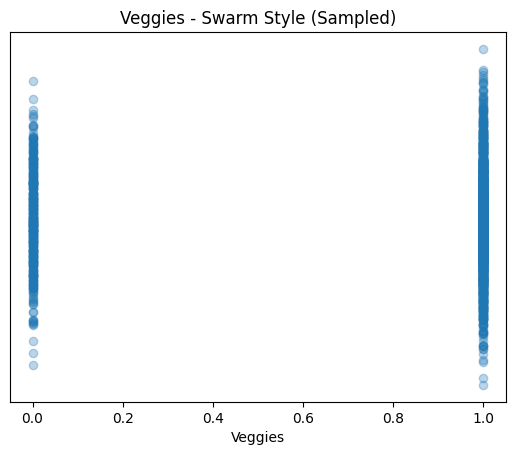

Plotting: HvyAlcoholConsump


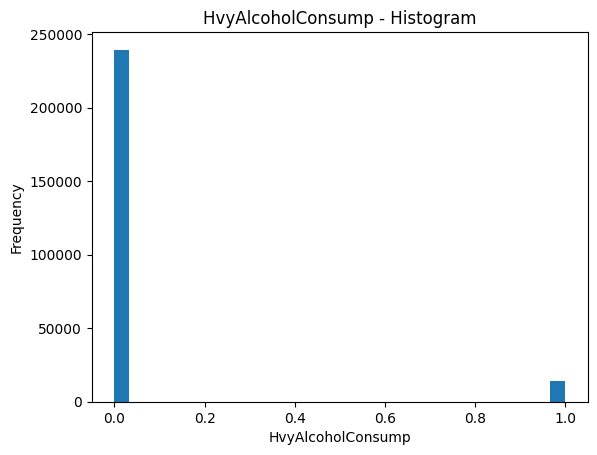

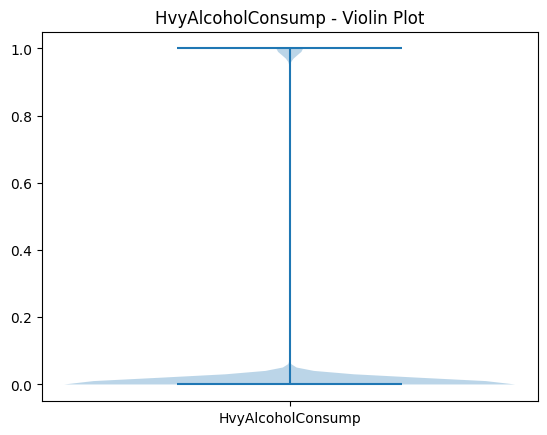

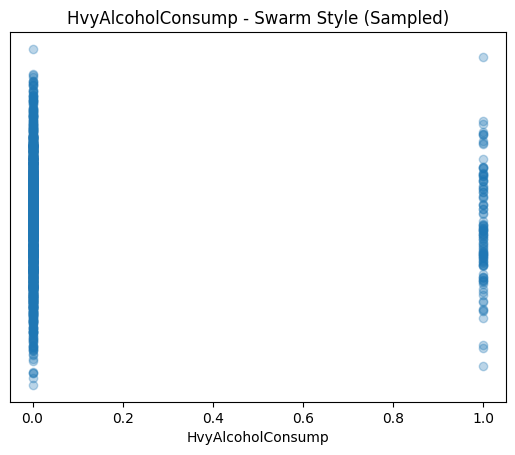

Plotting: AnyHealthcare


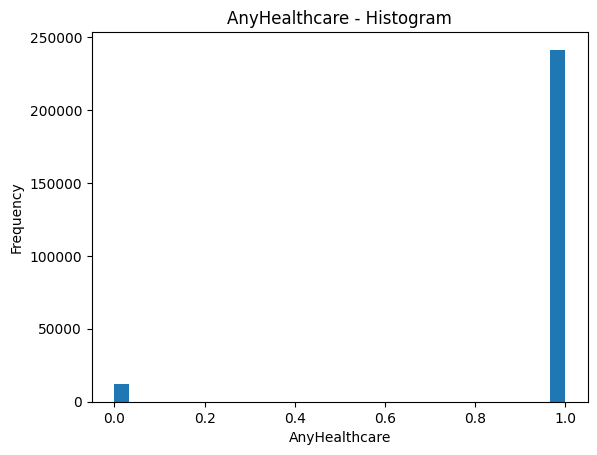

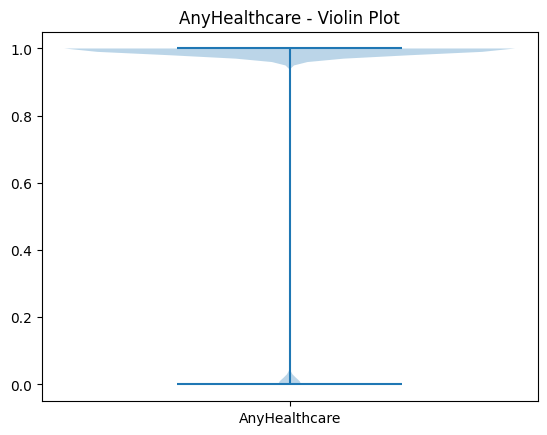

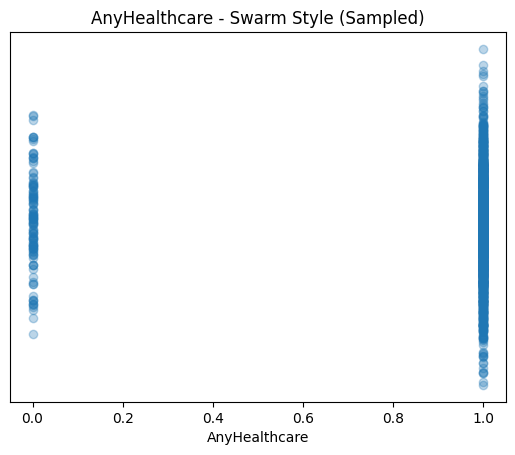

Plotting: NoDocbcCost


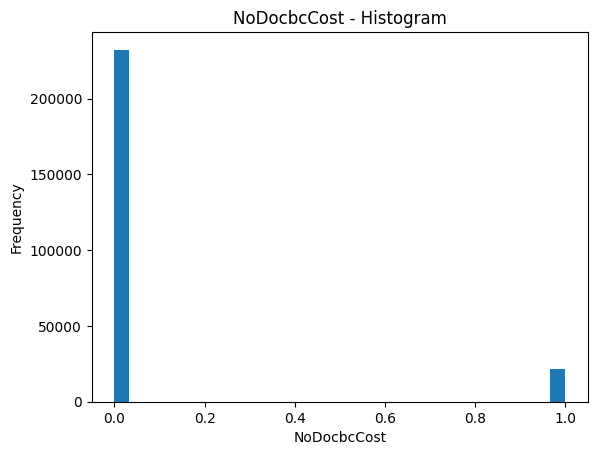

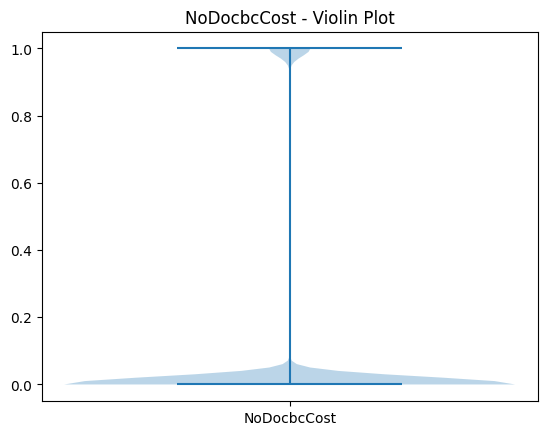

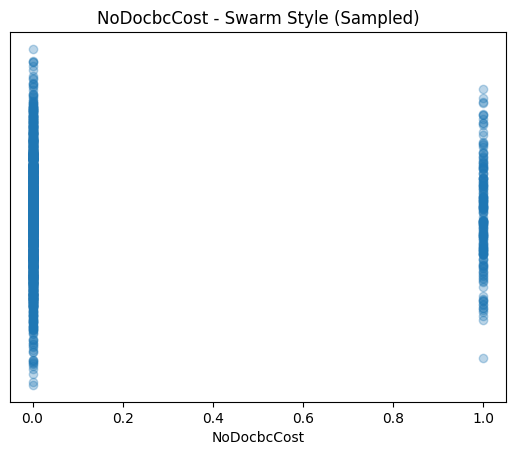

Plotting: GenHlth


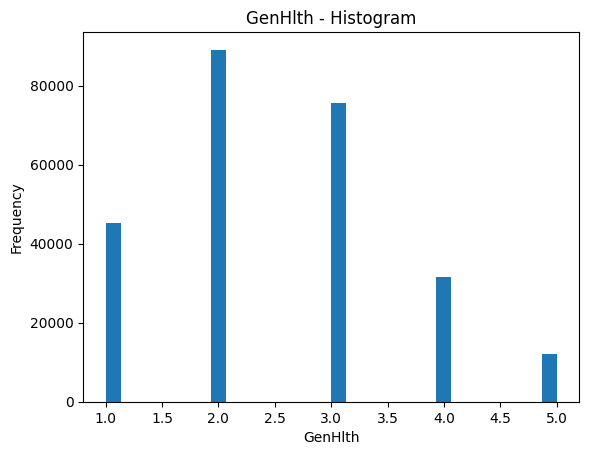

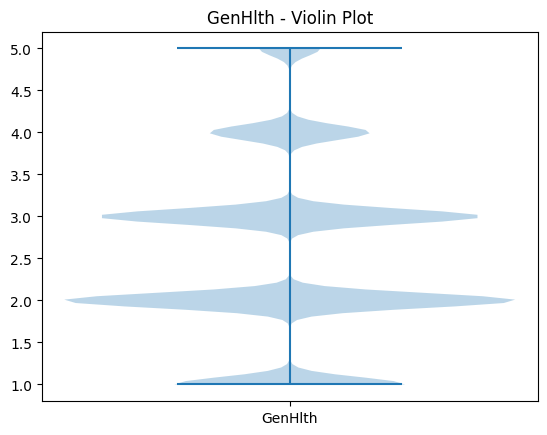

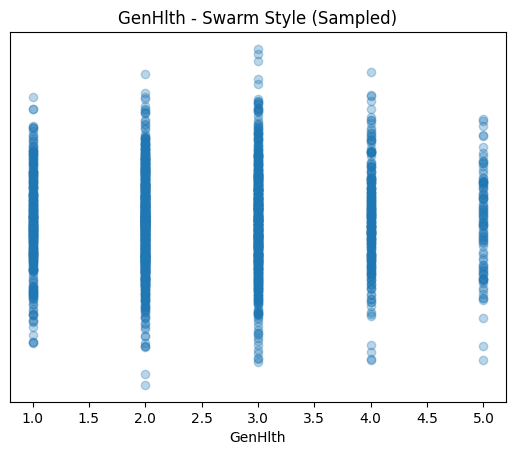

Plotting: MentHlth


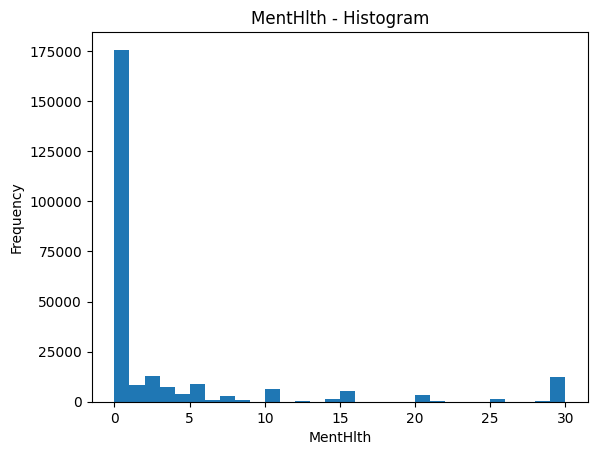

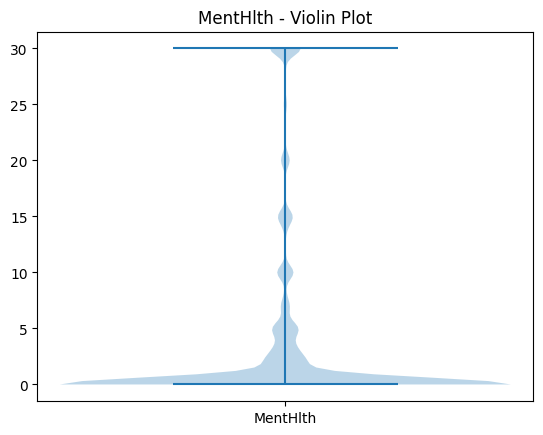

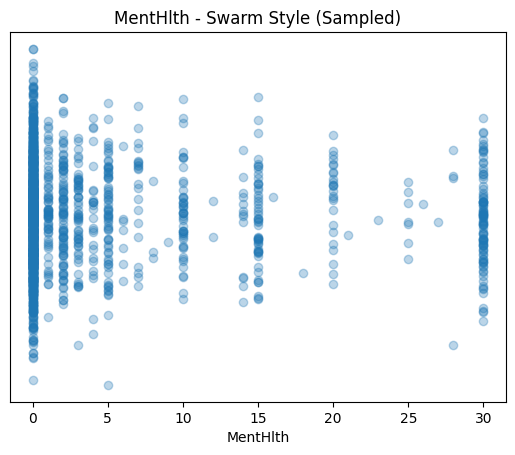

Plotting: PhysHlth


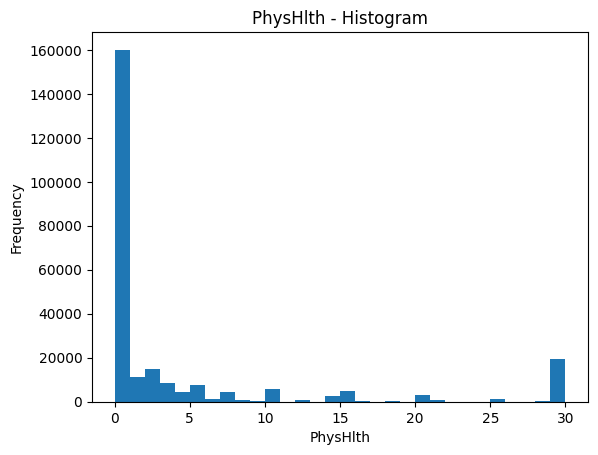

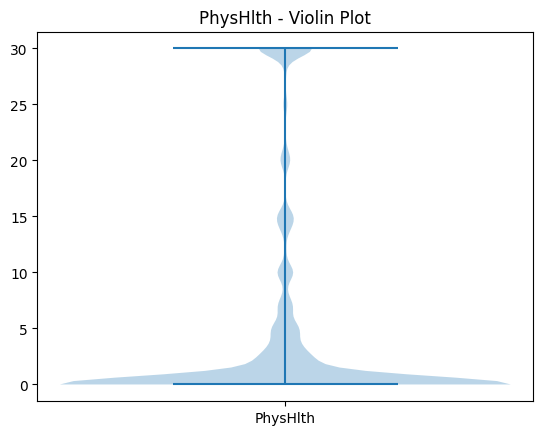

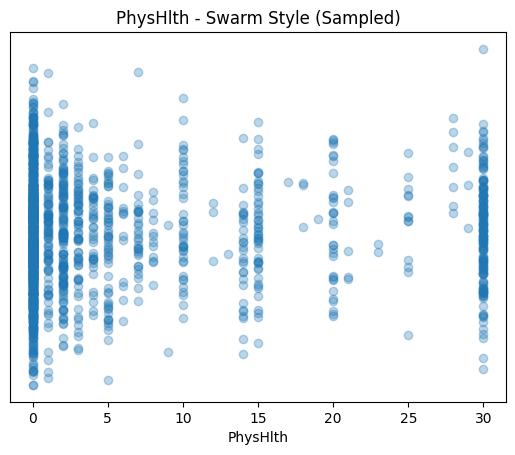

Plotting: DiffWalk


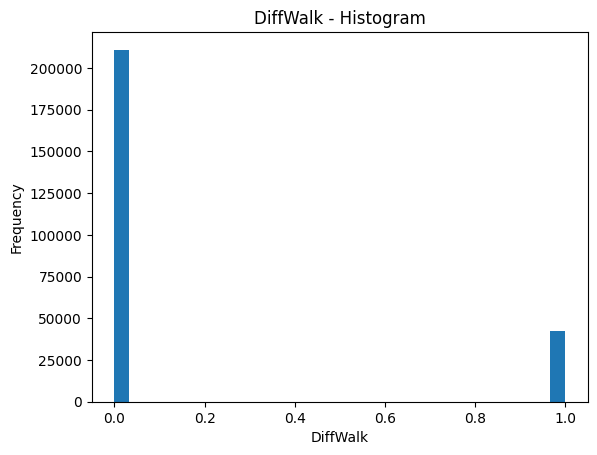

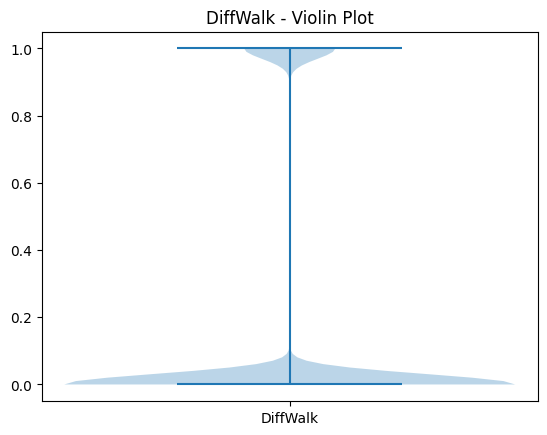

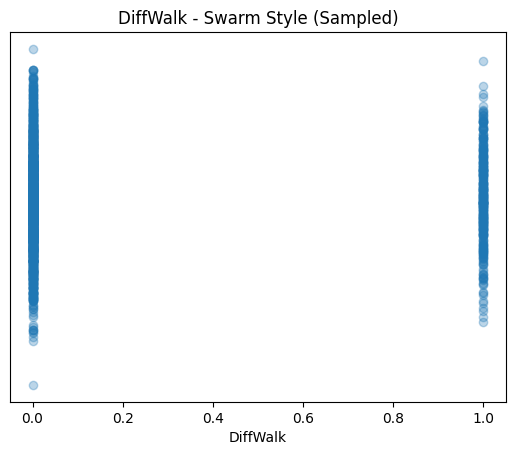

Plotting: Sex


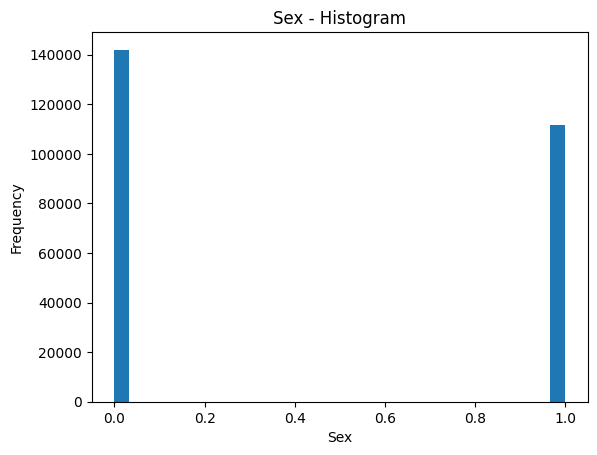

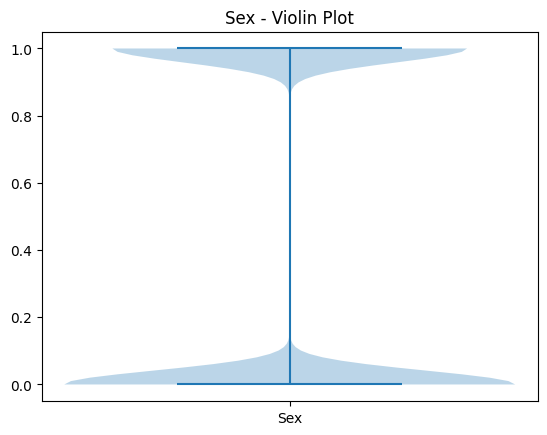

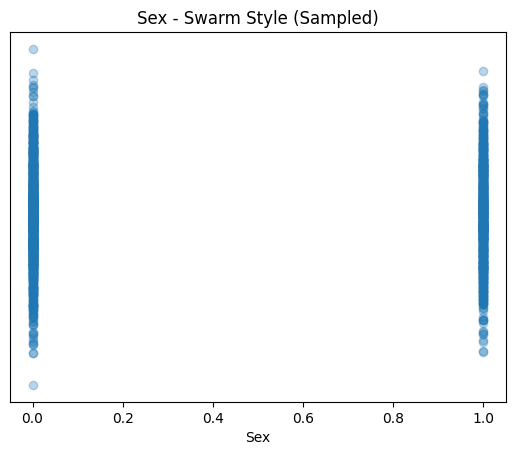

Plotting: Age


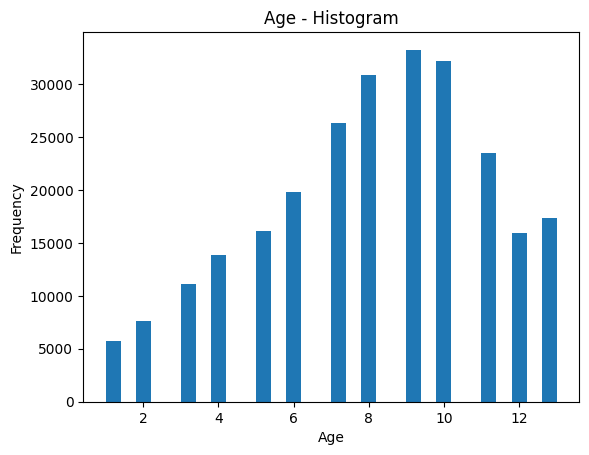

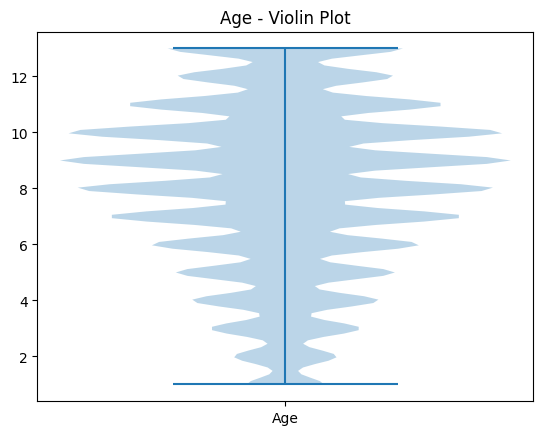

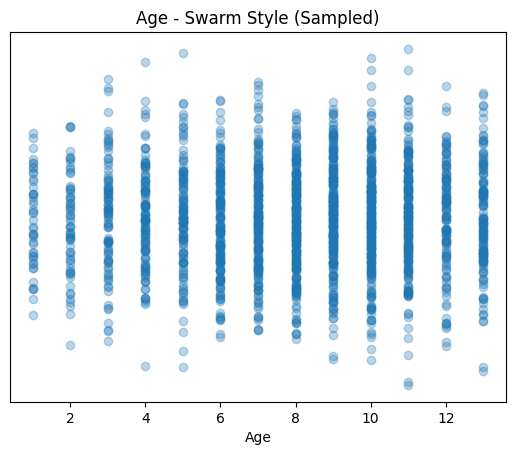

Plotting: Education


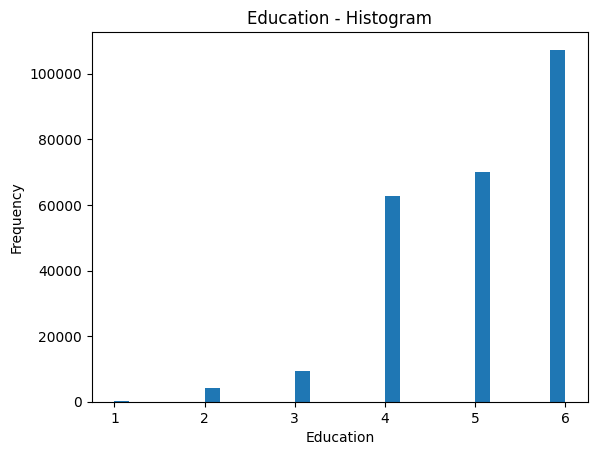

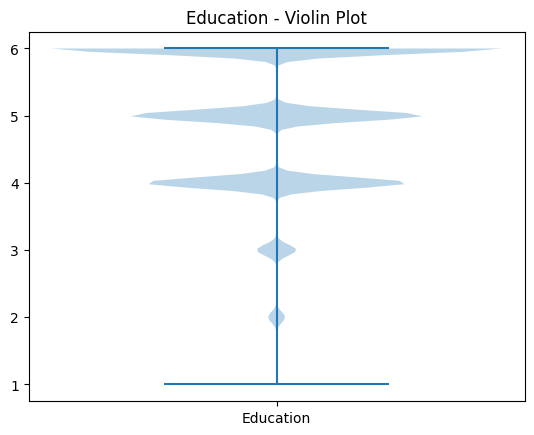

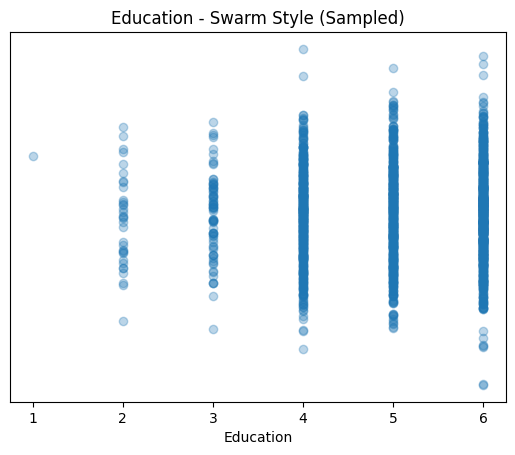

Plotting: Income


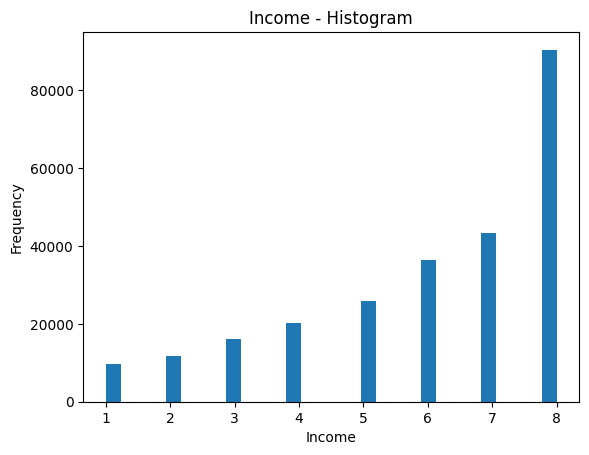

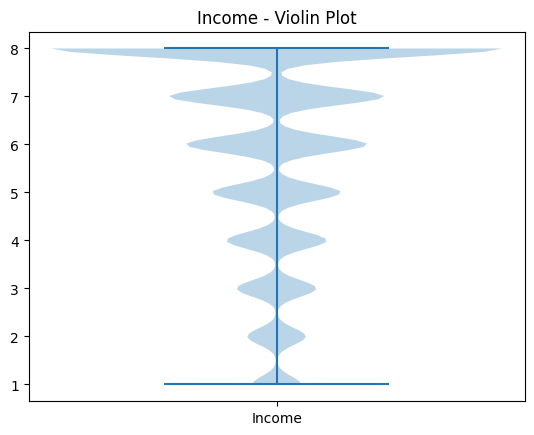

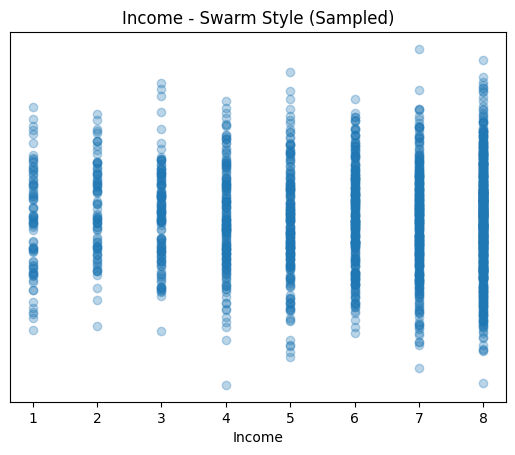

In [23]:
import matplotlib.pyplot as plt
import numpy as np

for col in df.columns:
    
    print(f"Plotting: {col}")
    
    data = df[col]
    
    # Histogram
    plt.figure()
    plt.hist(data, bins=30)
    plt.title(f"{col} - Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    
    # Violin Plot
    plt.figure()
    plt.violinplot(data)
    plt.title(f"{col} - Violin Plot")
    plt.xticks([1], [col])
    plt.show()
    
    # Swarm-style (sample to avoid freezing)
    sample = data.sample(2000) if len(data) > 2000 else data
    
    plt.figure()
    plt.scatter(sample, np.random.normal(0, 0.02, len(sample)), alpha=0.3)
    plt.title(f"{col} - Swarm Style (Sampled)")
    plt.yticks([])
    plt.xlabel(col)
    plt.show()

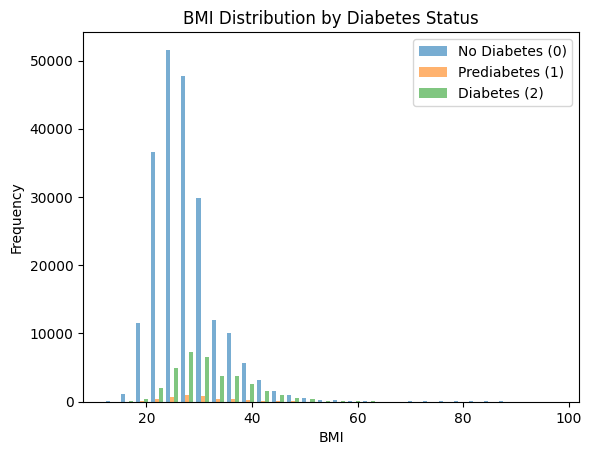

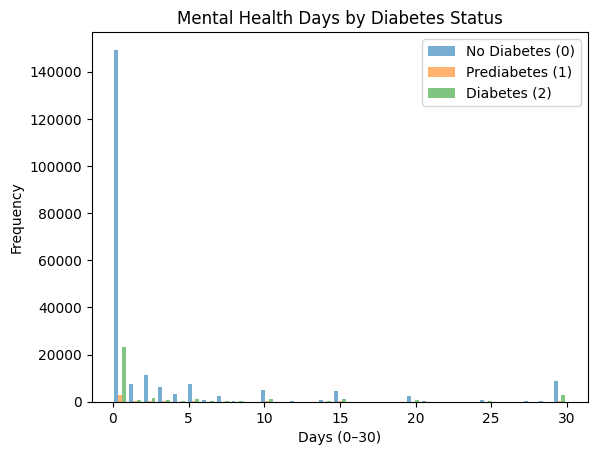

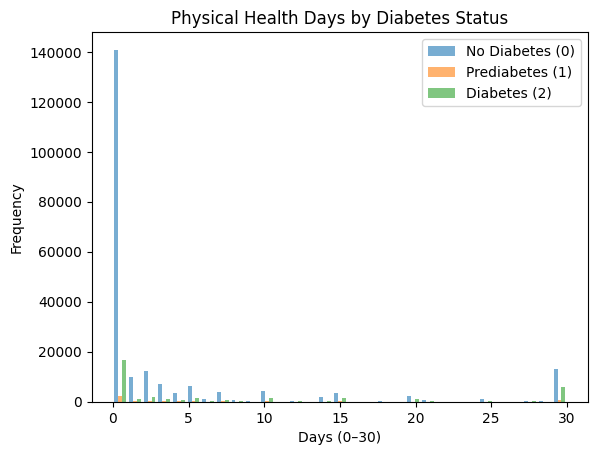

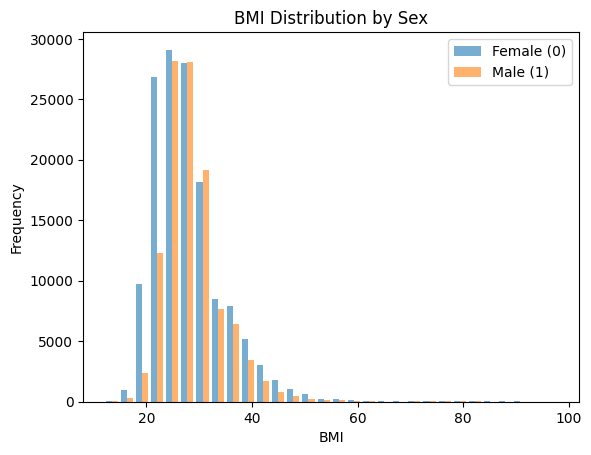

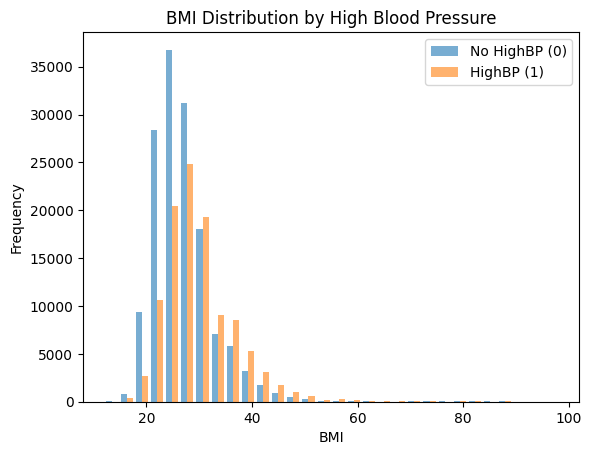

In [25]:
import matplotlib.pyplot as plt

groups = {
    "No Diabetes (0)": df.loc[df["Diabetes_012"] == 0, "BMI"],
    "Prediabetes (1)": df.loc[df["Diabetes_012"] == 1, "BMI"],
    "Diabetes (2)": df.loc[df["Diabetes_012"] == 2, "BMI"],
}

plt.figure()
plt.hist(groups.values(), bins=30, label=groups.keys(), alpha=0.6)
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.legend()
plt.show()

groups = {
    "No Diabetes (0)": df.loc[df["Diabetes_012"] == 0, "MentHlth"],
    "Prediabetes (1)": df.loc[df["Diabetes_012"] == 1, "MentHlth"],
    "Diabetes (2)": df.loc[df["Diabetes_012"] == 2, "MentHlth"],
}

plt.figure()
plt.hist(groups.values(), bins=31, label=groups.keys(), alpha=0.6)
plt.title("Mental Health Days by Diabetes Status")
plt.xlabel("Days (0–30)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

groups = {
    "No Diabetes (0)": df.loc[df["Diabetes_012"] == 0, "PhysHlth"],
    "Prediabetes (1)": df.loc[df["Diabetes_012"] == 1, "PhysHlth"],
    "Diabetes (2)": df.loc[df["Diabetes_012"] == 2, "PhysHlth"],
}

plt.figure()
plt.hist(groups.values(), bins=31, label=groups.keys(), alpha=0.6)
plt.title("Physical Health Days by Diabetes Status")
plt.xlabel("Days (0–30)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

groups = {
    "Female (0)": df.loc[df["Sex"] == 0, "BMI"],
    "Male (1)": df.loc[df["Sex"] == 1, "BMI"],
}

plt.figure()
plt.hist(groups.values(), bins=30, label=groups.keys(), alpha=0.6)
plt.title("BMI Distribution by Sex")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.legend()
plt.show()
groups = {
    "No HighBP (0)": df.loc[df["HighBP"] == 0, "BMI"],
    "HighBP (1)": df.loc[df["HighBP"] == 1, "BMI"],
}

plt.figure()
plt.hist(groups.values(), bins=30, label=groups.keys(), alpha=0.6)
plt.title("BMI Distribution by High Blood Pressure")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.legend()
plt.show()

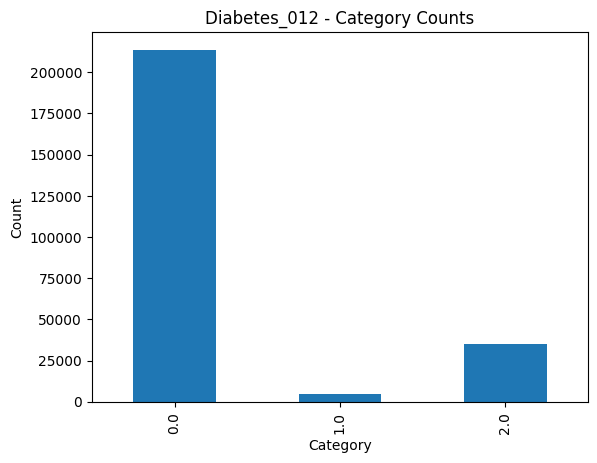

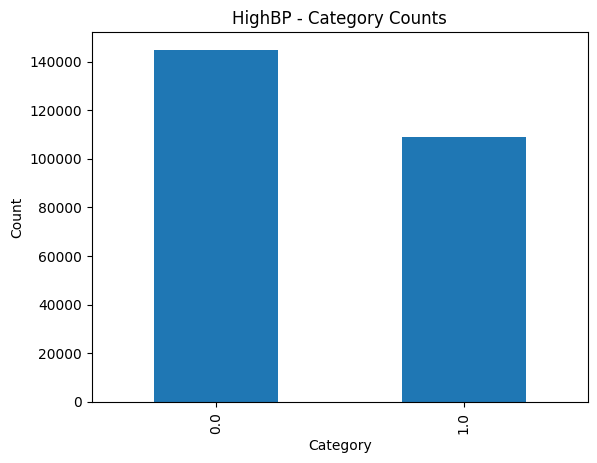

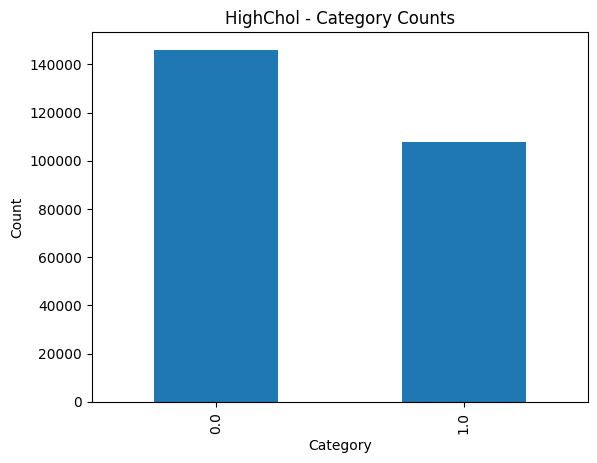

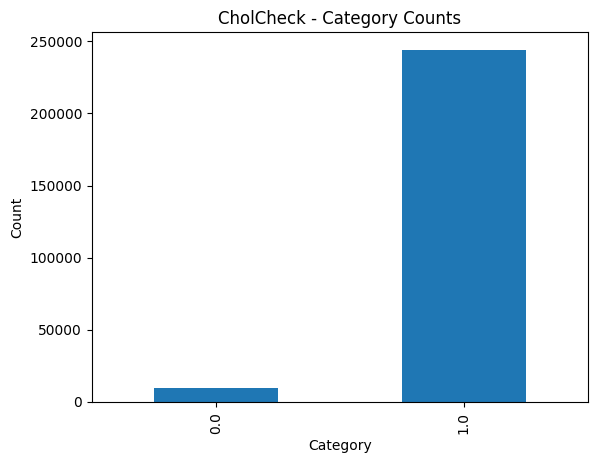

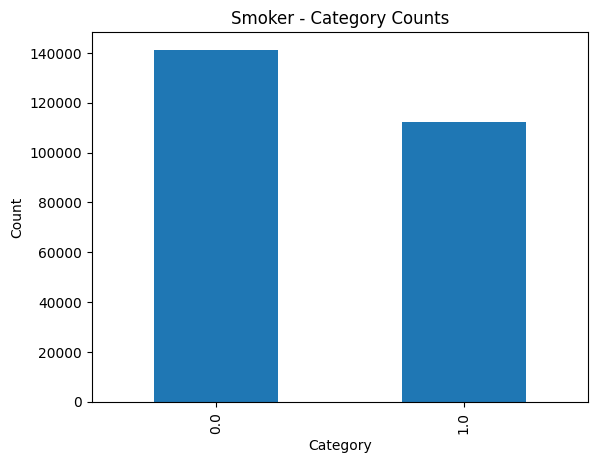

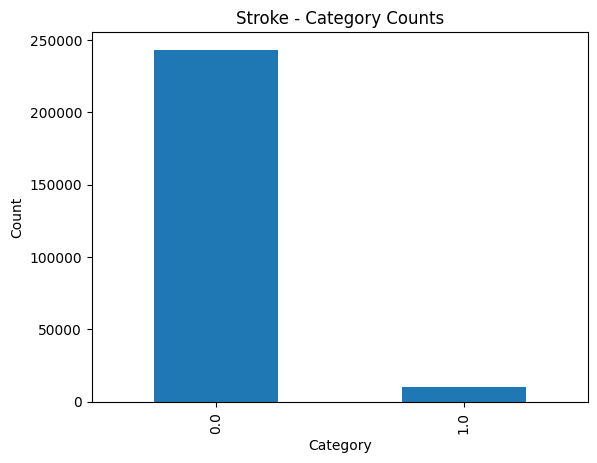

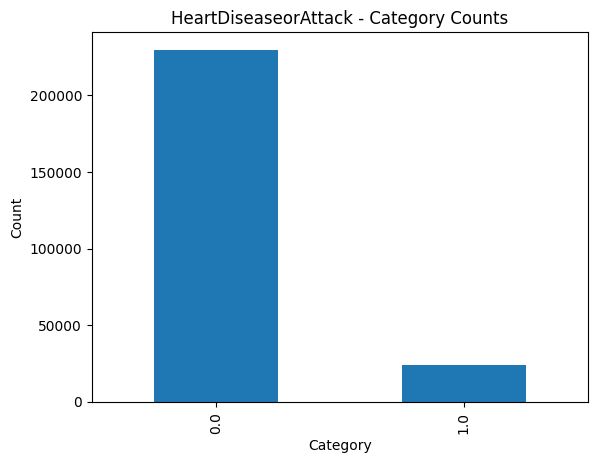

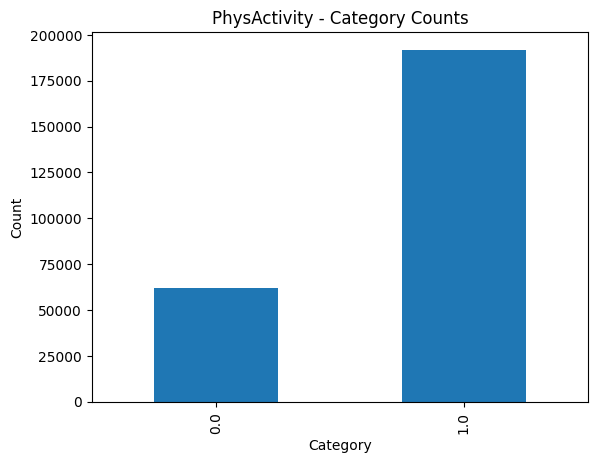

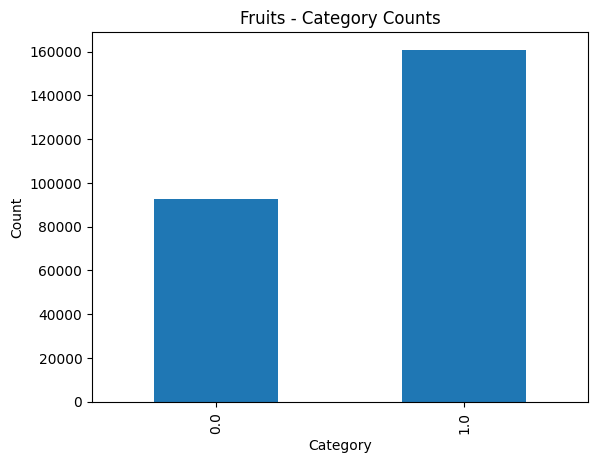

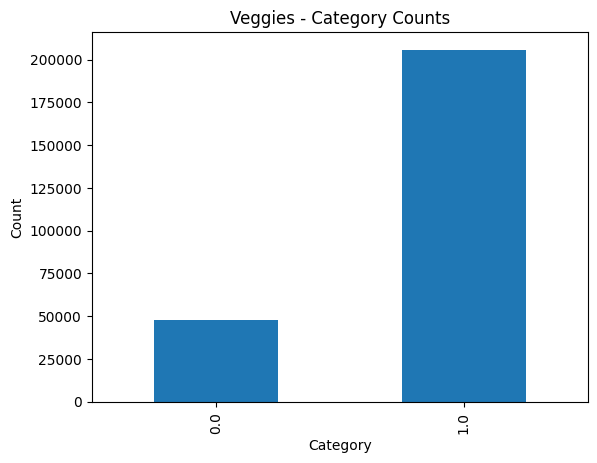

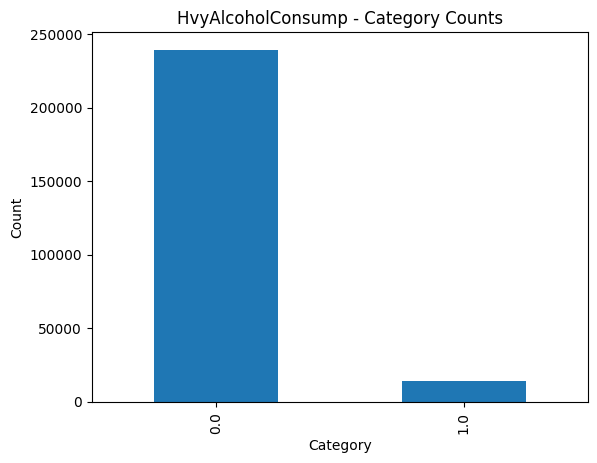

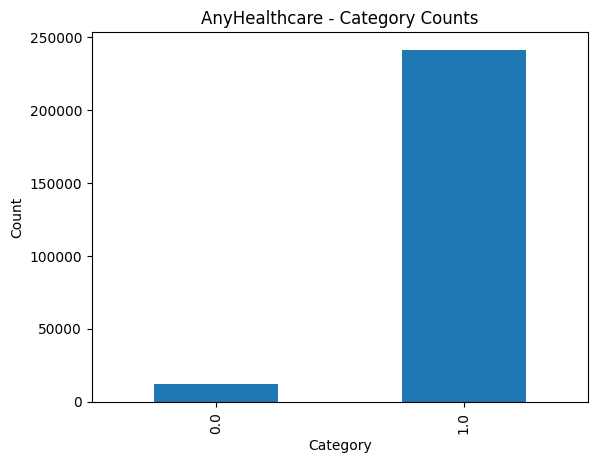

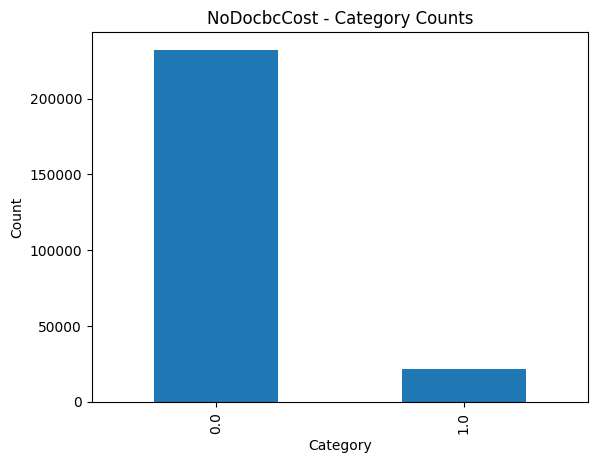

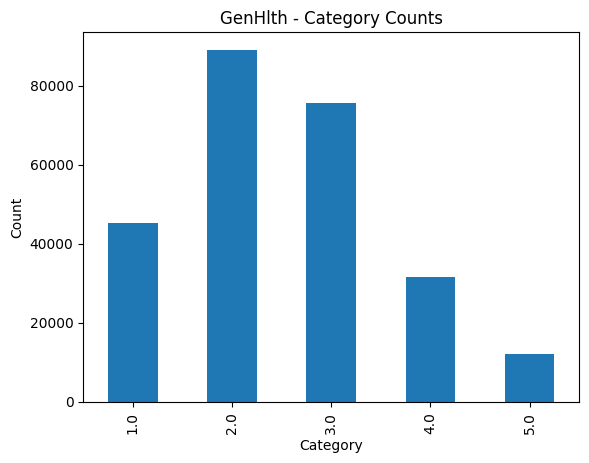

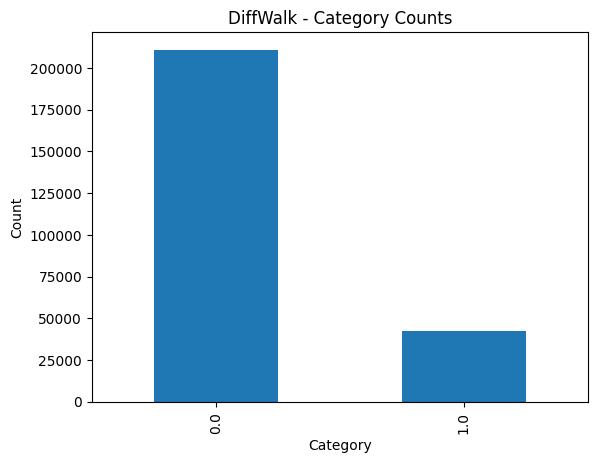

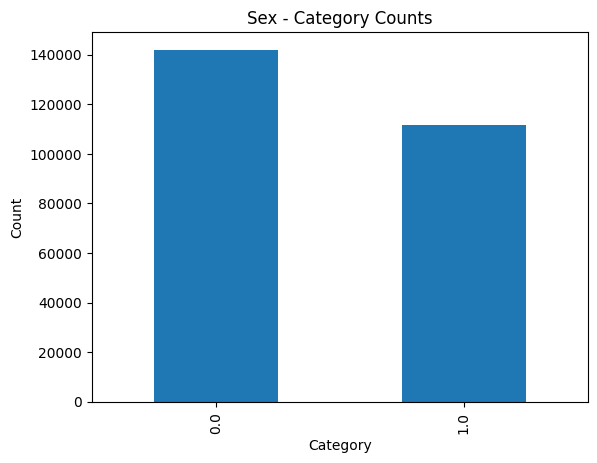

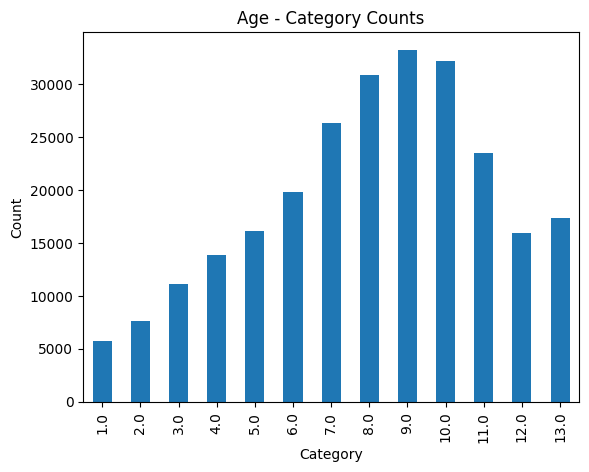

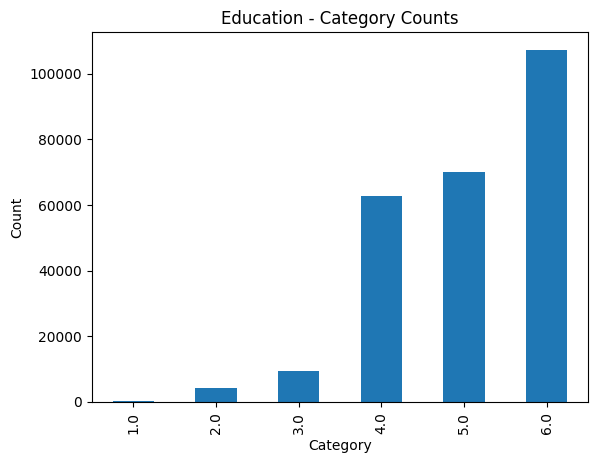

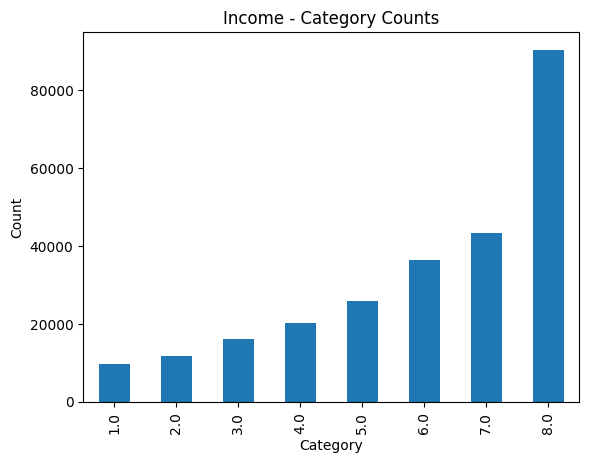

In [27]:
import matplotlib.pyplot as plt

for col in df.columns:
    
    if df[col].nunique() <= 15:
        
        plt.figure()
        df[col].value_counts().sort_index().plot(kind="bar")
        plt.title(f"{col} - Category Counts")
        plt.xlabel("Category")
        plt.ylabel("Count")
        plt.show()

In [28]:
summary_stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0]
})

summary_stats

,Mean,Median,Mode
Diabetes_012,0.296921,0.0,0.0
HighBP,0.429001,0.0,0.0
HighChol,0.424121,0.0,0.0
CholCheck,0.962670,1.0,1.0
BMI,28.382364,27.0,27.0
Smoker,0.443169,0.0,0.0
Stroke,0.040571,0.0,0.0
HeartDiseaseorAttack,0.094186,0.0,0.0
PhysActivity,0.756544,1.0,1.0
Fruits,0.634256,1.0,1.0


The distributions in this dataset are largely consistent with expectations for population-level health data and appear appropriate for further analysis. Most binary variables, such as HighBP, are clearly imbalanced, with more individuals reporting no condition than having the condition. BMI shows a positively skewed distribution with a long right tail and visible high-value outliers extending well above 60, indicating extreme obesity cases. When grouped by HighBP and Diabetes_012, the BMI distributions shift noticeably to the right for individuals with high blood pressure and diabetes, suggesting higher BMI is associated with these conditions. Similarly, Mental Health Days is heavily zero-inflated across all diabetes groups, but individuals with diabetes display relatively more nonzero days and slightly heavier right tails, indicating worse reported mental health. GenHlth clusters strongly in middle categories, suggesting most respondents report average health rather than extremes. Minimum and maximum values align with expected survey bounds (e.g., health days between 0 and 30). Bin width influences how clearly spikes at 0 and upper values appear, with narrower bins revealing clustering more distinctly. Overall, the data are not normally distributed; most variables are skewed or categorical, but the patterns are realistic and the dataset appears usable for modeling and further statistical analysis.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

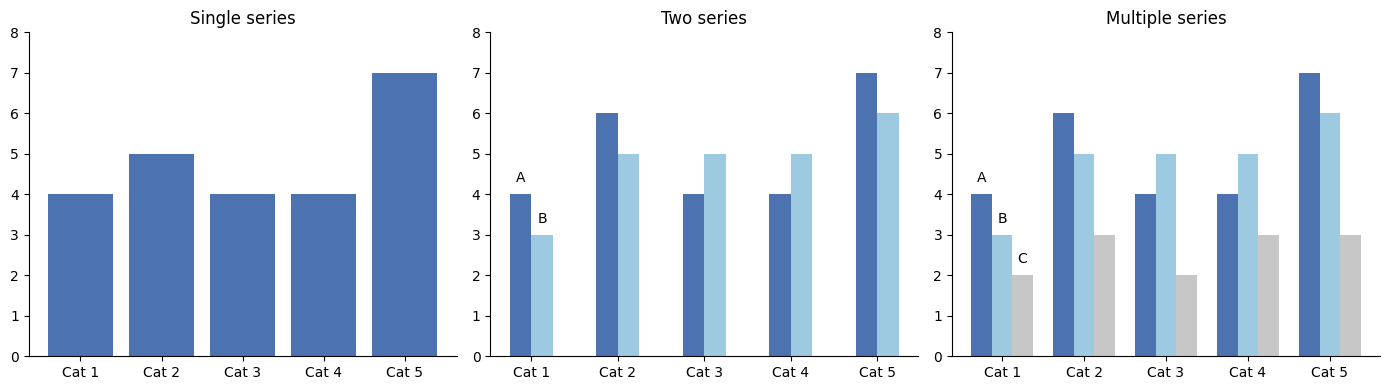

In [30]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
x = np.arange(len(categories))
width = 0.25

single = [4, 5, 4, 4, 7]
series_a = [4, 6, 4, 4, 7]
series_b = [3, 5, 5, 5, 6]
series_c = [2, 3, 2, 3, 3]

fig, axs = plt.subplots(1, 3, figsize=(14,4))

axs[0].bar(categories, single, color="#4c72b0")
axs[0].set_title("Single series")
axs[0].set_ylim(0,8)

bars_a = axs[1].bar(x - width/2, series_a, width, color="#4c72b0")
bars_b = axs[1].bar(x + width/2, series_b, width, color="#9ecae1")

axs[1].set_xticks(x)
axs[1].set_xticklabels(categories)
axs[1].set_title("Two series")
axs[1].set_ylim(0,8)


axs[1].text(x[0] - width/2, series_a[0] + 0.3, "A", ha="center")
axs[1].text(x[0] + width/2, series_b[0] + 0.3, "B", ha="center")


bars_a = axs[2].bar(x - width, series_a, width, color="#4c72b0")
bars_b = axs[2].bar(x, series_b, width, color="#9ecae1")
bars_c = axs[2].bar(x + width, series_c, width, color="#c7c7c7")

axs[2].set_xticks(x)
axs[2].set_xticklabels(categories)
axs[2].set_title("Multiple series")
axs[2].set_ylim(0,8)

axs[2].text(x[0] - width, series_a[0] + 0.3, "A", ha="center")
axs[2].text(x[0], series_b[0] + 0.3, "B", ha="center")
axs[2].text(x[0] + width, series_c[0] + 0.3, "C", ha="center")


for ax in axs:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()